# Predicciones combinadas

se ponderan las predicciones en función del error, y se comparan dichas predicciones combinadas respecto a cada una 


In [1]:
import numpy as np
import pandas as pd
import itertools
import statsmodels.api as sm
import time
import json
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.dates as mdates
warnings.filterwarnings("ignore")
#plt.style.use("seaborn-v0_8-darkgrid")
#sns.set_palette("viridis")


In [2]:
date_close =  pd.read_csv("../../../data/csv/EC_GER_Weekly.csv")
df_data_close = pd.DataFrame(date_close.copy()) # copia del df de precios de cierre como df
#df_data_close["Start date"] = pd.to_datetime(df_data_close["Start date"])
df_data_close = df_data_close.sort_values(by="Start date", ascending=True) # se ordena por fecha ascendente
df_data_close = df_data_close.rename(columns={
    "Start date": "Date",
    "value": "original"
})

df_data_close.head()


,Date,original
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


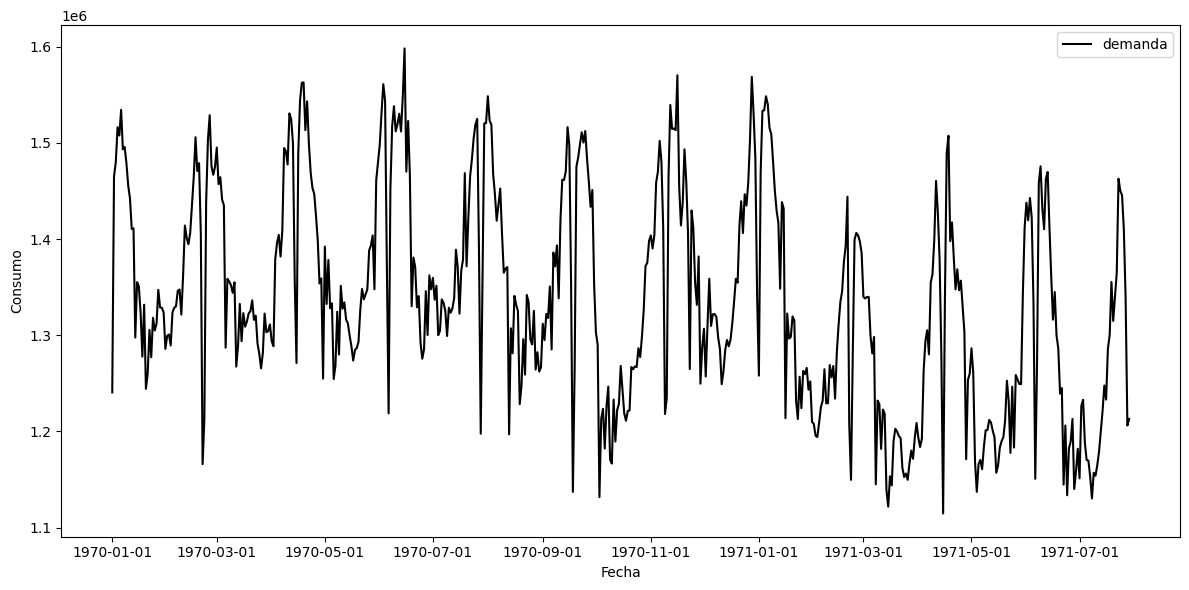

In [3]:
# # se grafican los datos de consumo de forma semanal
plt.figure(figsize=(12,6))
plt.plot(df_data_close["Date"], df_data_close["original"], label="demanda", color="black")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [4]:
# se cargan las predicciones y las medianas de los mapes correspondientes
folder_route = "../../../data/preds_energy_models/"
list_files = [
    "neuralprophet_preds.json",
    "rnn_preds.json",
    "xgboost_preds.json",
    "SARIMA_preds.json",
]

list_preds_and_mapes = []  # se guardan los errores promedio y las predicciones
for element in list_files: # recorre los nombres
    path = os.path.join(folder_route, element) #abre el json de nombre correspondiente
    with open(path, "r") as f: # lo abre en modo lectura
        data = json.load(f) # carga la info del archivo
        
        base_name = element.replace(".json", "") # quita la extensión .json del nombre
        preds = data["predictions"], # data devuelve la info dentro de un array, por eso se toma la primera posición
        
        list_preds_and_mapes.append({
            "name": base_name, # nombre del modelo asociado
            "mape_val": float(data["mape_val"]), # registro media mape
            "mae_val":  float(data["mae_val"]), # registro mediamediana mae
            "smape_val": float(data["smape_val"]), # registro media rmse
            "rmse_val": float(data["rmse_val"]), # registro media rmse
            "forecasts": preds[0],
        })
list_preds_and_mapes[2]

{'name': 'xgboost_preds',
 'mape_val': 0.024728456512093544,
 'mae_val': 31344.583984375,
 'smape_val': 0.024733125650635297,
 'rmse_val': 39781.38821107177,
 'forecasts': [{'Date': '2025-01-20', 'pred': 1458093.375},
  {'Date': '2025-01-27', 'pred': 1444869.75},
  {'Date': '2025-02-03', 'pred': 1395853.5},
  {'Date': '2025-02-10', 'pred': 1394908.375},
  {'Date': '2025-02-17', 'pred': 1374644.125},
  {'Date': '2025-02-24', 'pred': 1409041.75},
  {'Date': '2025-03-03', 'pred': 1349080.625},
  {'Date': '2025-03-10', 'pred': 1350309.75},
  {'Date': '2025-03-17', 'pred': 1301910.375},
  {'Date': '2025-03-24', 'pred': 1249500.375},
  {'Date': '2025-03-31', 'pred': 1260132.375},
  {'Date': '2025-04-07', 'pred': 1241057.625},
  {'Date': '2025-04-14', 'pred': 1233518.125},
  {'Date': '2025-04-21', 'pred': 1252059.375},
  {'Date': '2025-04-28', 'pred': 1223202.0},
  {'Date': '2025-05-05', 'pred': 1206595.75},
  {'Date': '2025-05-12', 'pred': 1168068.125},
  {'Date': '2025-05-19', 'pred': 11976

In [5]:
for element in list_preds_and_mapes:
    print(f"modelo: {element['name']}, logitud: {len(element['forecasts'])}")

modelo: neuralprophet_preds, logitud: 58
modelo: rnn_preds, logitud: 58
modelo: xgboost_preds, logitud: 51
modelo: SARIMA_preds, logitud: 58


Como las predicciones son de distinta longitud (por los lags requeridos y eliminnación de nan) se hace la comparación bajo el conjunto de predicciones de longitud mínima, es decir, se comparan las predicciones respecto a las 46 observaciones de la rnn. Para ello se toma el conjunto de predicciones de la rnn como base y se filtra por fecha, obteniendo las predicciones cuya fecha coincide

In [6]:
rnn_preds = None
xgboost_preds = None
neuralprophet_preds = None
SARIMA_manual_preds = None

for item in list_preds_and_mapes:
    if item["name"] == "rnn_preds":
        rnn_preds = item["forecasts"]
        break

for item in list_preds_and_mapes:
    if item["name"] == "xgboost_preds":
        xgboost_preds = item["forecasts"]
        break

for item in list_preds_and_mapes:
    if item["name"] == "neuralprophet_preds":
        neuralprophet_preds = item["forecasts"]
        break

for item in list_preds_and_mapes:
    if item["name"] == "SARIMA_preds":
        SARIMA_preds = item["forecasts"]
        break



se crean dataframes con las preds

In [7]:
data_rnn = pd.DataFrame({
    "Date": [el["Date"] for el in rnn_preds],
    "Pred_RNN": [el["pred"] for el in rnn_preds]
})

data_SARIMA = pd.DataFrame({
    "Date": [el["Date"] for el in SARIMA_preds],
    "Pred_SARIMA": [el["pred"] for el in SARIMA_preds]
})

data_xgboost  = pd.DataFrame({
    "Date": [el["Date"] for el in xgboost_preds],
    "Pred_xgboost": [el["pred"] for el in xgboost_preds]
})

data_neuralprophet = pd.DataFrame({
    "Date": [el["Date"] for el in neuralprophet_preds],
    "Pred_neuralprophet": [el["pred"] for el in neuralprophet_preds]
})

# se toman las predicciones de SARIMA que tienen la misma fecha
data_preds = data_rnn.merge(
    data_SARIMA,
    how="inner",
    on="Date"
)

# se une el df con las preds de neural prophet
data_preds = data_preds.merge(
    data_neuralprophet,
    how="inner",
    on="Date"
).merge(
    data_xgboost,
    how="inner",
    on="Date"
).merge(
    df_data_close,
    how="inner",
    on="Date"
)
data_preds.head(30)


,Date,Pred_RNN,Pred_SARIMA,Pred_neuralprophet,Pred_xgboost,original
0,2025-01-20,1479763.375,1.467921e+06,1516576.250,1458093.375,1.475585e+06
1,2025-01-27,1457192.750,1.431807e+06,1485909.250,1444869.750,1.432038e+06
2,2025-02-03,1408621.125,1.433362e+06,1369616.125,1395853.500,1.410254e+06
3,2025-02-10,1383910.875,1.417213e+06,1443734.750,1394908.375,1.462596e+06
4,2025-02-17,1395305.125,1.389440e+06,1439647.500,1374644.125,1.469661e+06
5,2025-02-24,1382289.500,1.387928e+06,1438928.875,1409041.750,1.412902e+06
6,2025-03-03,1369692.125,1.375800e+06,1360988.375,1349080.625,1.361709e+06
7,2025-03-10,1330715.375,1.378295e+06,1359486.625,1350309.750,1.316209e+06
8,2025-03-17,1305008.250,1.353564e+06,1353641.500,1301910.375,1.344922e+06
9,2025-03-24,1294623.500,1.327815e+06,1324002.250,1249500.375,1.299947e+06


In [8]:
split = df_data_close.iloc[-len(data_preds)]["Date"]
split

'2025-01-20'

se crea predicción combinada en función de los inversos de los mapes

In [9]:
# diccionario que guarda los mapes de cada modelo
mapes_list = {
    element["name"]: element["mape_val"] for element in list_preds_and_mapes
}
mapes_list

{'neuralprophet_preds': 0.02729680254169635,
 'rnn_preds': 0.029926634861861,
 'xgboost_preds': 0.024728456512093544,
 'SARIMA_preds': 0.04066826242899603}

In [10]:
# pesos inversamente proporcionales al MAPE
inv_mapes_list = {k: 1/v for k, v in mapes_list.items()}

# suma de los inversos
sum_inv_mapes = sum(inv_mapes_list.values())

# normalización correcta
weights_list = {k: v / sum_inv_mapes for k, v in inv_mapes_list.items()}

sum(weights_list.values())  # debe dar 1

1.0

In [11]:
# predicción combinada

data_preds["pred_emsemble"] = (weights_list["rnn_preds"] * data_preds["Pred_RNN"] +
    weights_list["SARIMA_preds"] * data_preds["Pred_SARIMA"] +
    weights_list["neuralprophet_preds"] * data_preds["Pred_neuralprophet"] +
    weights_list["xgboost_preds"] * data_preds["Pred_xgboost"])

data_preds.head()

,Date,Pred_RNN,Pred_SARIMA,Pred_neuralprophet,Pred_xgboost,original,pred_emsemble
0,2025-01-20,1479763.375,1.467921e+06,1516576.250,1458093.375,1.475585e+06,1.481104e+06
1,2025-01-27,1457192.750,1.431807e+06,1485909.250,1444869.750,1.432038e+06,1.456670e+06
2,2025-02-03,1408621.125,1.433362e+06,1369616.125,1395853.500,1.410254e+06,1.398724e+06
3,2025-02-10,1383910.875,1.417213e+06,1443734.750,1394908.375,1.462596e+06,1.409490e+06
4,2025-02-17,1395305.125,1.389440e+06,1439647.500,1374644.125,1.469661e+06,1.400078e+06


In [12]:
# comparación metricas preds ensemble
# métricas de error

y_true = data_preds["original"].values
y_pred_ensemble = data_preds["pred_emsemble"].values
smape_fn = MeanAbsolutePercentageError(symmetric=True)
mae  = mean_absolute_error(y_true, y_pred_ensemble)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_ensemble))
mape = mean_absolute_percentage_error(y_true, y_pred_ensemble)
smape = smape_fn(y_true, y_pred_ensemble)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape*100:.4f}%")
print(f"sMAPE: {smape*100:.4f}%")

MAE: 29194.839566525436
RMSE: 37842.1475698764
MAPE: 2.2998%
sMAPE: 2.2990%


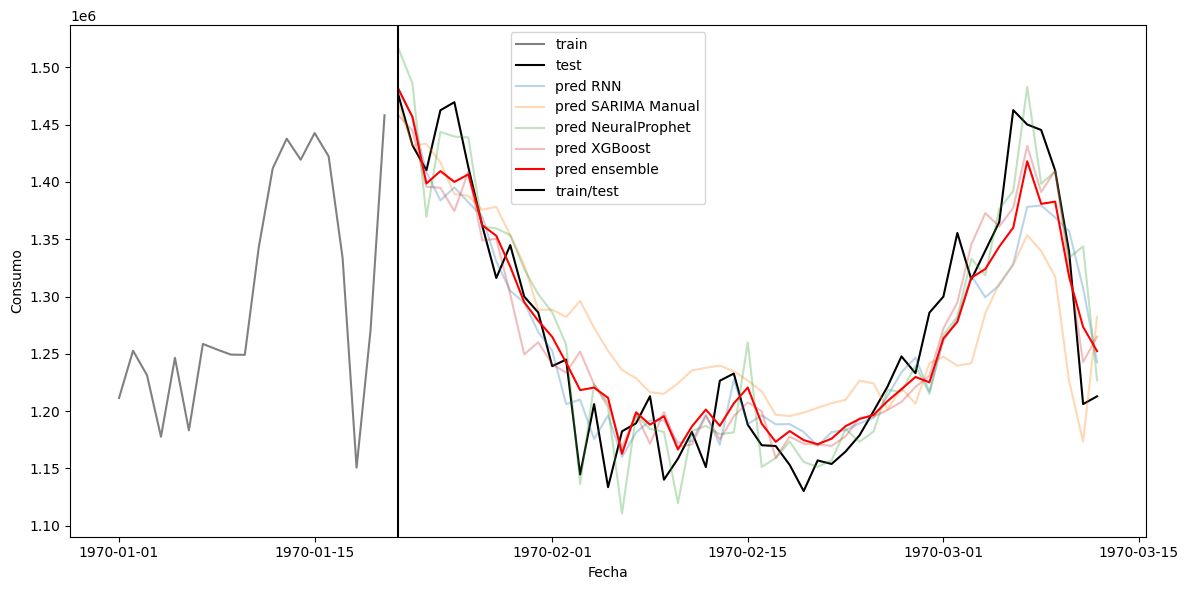

In [13]:
# grpafica con ensemble 
# se grafican los datos 
# # se grafican los datos de consumo de forma semanal
plt.figure(figsize=(12,6))
#plt.plot(df_data_close["Date"][:-len(data_preds)], df_data_close["original"][:-len(data_preds)], label="train", color="gray")
plt.plot(df_data_close["Date"][-len(data_preds) - 20:-len(data_preds)], df_data_close["original"][-len(data_preds) - 20:-len(data_preds)], label="train", color="gray")
plt.plot(df_data_close["Date"][-len(data_preds):], df_data_close["original"][-len(data_preds):], label="test", color="black")
plt.plot(data_preds["Date"], data_preds["Pred_RNN"], label="pred RNN", alpha=0.3)
plt.plot(data_preds["Date"], data_preds["Pred_SARIMA"], label="pred SARIMA Manual", alpha=0.3)
plt.plot(data_preds["Date"], data_preds["Pred_neuralprophet"], label="pred NeuralProphet", alpha=0.3)
plt.plot(data_preds["Date"], data_preds["Pred_xgboost"], label="pred XGBoost", alpha=0.3)
plt.plot(data_preds["Date"], data_preds["pred_emsemble"], label="pred ensemble", alpha=1, color='red')
plt.axvline(split, color="black", label="train/test")
#plt.plot(df_data_close["Date"], df_data_close["original"], label="demanda")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [14]:
# se crea lista de mapes y demas errores para alfinal unir en una sola tabla
mapes_list["ensemble"] = mape

maes_list = {
    element["name"]: element["mae_val"] for element in list_preds_and_mapes
}
maes_list["ensemble"] = mae

rmse_list = {
    element["name"]: element["rmse_val"] for element in list_preds_and_mapes
}
rmse_list["ensemble"] = rmse

smapes_list = {
    element["name"]: element["smape_val"] for element in list_preds_and_mapes
}
smapes_list["ensemble"] = smape

# se construyen los datasets

errors_df = pd.DataFrame({
    "modelo": [el.replace("_preds", "") for el in mapes_list.keys()],
    "mape": [f"{el * 100:.4f}%" for el in mapes_list.values()],
    "smape": [f"{el * 100:.4f}%" for el in smapes_list.values()],
    "mae": maes_list.values(),
    "rmse": rmse_list.values(),
})

errors_df.sort_values(by="mape")


,modelo,mape,smape,mae,rmse
4,ensemble,2.2998%,2.2990%,29194.839567,37842.147570
2,xgboost,2.4728%,2.4733%,31344.583984,39781.388211
0,neuralprophet,2.7297%,2.7209%,34857.241236,47320.152375
1,rnn,2.9927%,2.9934%,38567.141297,50811.059375
3,SARIMA,4.0668%,4.0362%,51313.516011,63161.652014
